# Modelagem Preditiva

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

import sys
from pathlib import Path

# adiciona a raiz do projeto ao caminho de busca do Python
sys.path.append(str(Path().resolve().parent))

## 1. Obtenção dos dados

In [2]:
df_train = pd.read_csv('../data/processed/train_clean.csv')
df_test = pd.read_csv('../data/processed/test_clean.csv')

dicionario = pd.read_csv('../data/external/dictionary_no_identifiers.csv')

In [3]:
df_train.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Standard,809.98,26.822620,265,0,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,February,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,219,0,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,March,33,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,267,0,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,April,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,268,0,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,May,23,Scientist,19114.12,1824.843333,3,4.0,3.0,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,269,0,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


## 2. Perguntas norteadoras de negócio

Nesta etapa, objetivamos responter às seguintes perguntas de negócio:

- Um modelo de Machine Learning consegue classificar o score de crédito dos clientes com boa performance?
- Quais variáveis podem ter maior relação com a capacidade de pagamento dos clientes?
- Qual perfil de cliente possui maior probabilidade de ser classificado com score “Poor”? 

## 3. Metodologia

Usaremos três algoritmos de classificação, que serão testados utilizando o método de validação cruzada **Stratified K-Fold**, que é mais adequado para dados que têm as suas classes desbalanceadas. Além disso, os hiperparâmetros dos modelos serão otimizados usando a estratégia **Random Search**, que é mais vantajoso em algoritmos com muitos hiperparâmetros. Os modelos a serem analisados são:

- **Regressão Logística**: é um modelo simples e fácil de interpretar, além de ser uma boa referência para comparar modelos mais complexos.
- **Random Forest**: é um modelo que geralmente apresenta excelente desempenho e é robusto a outliers, porém é menos interpretável. (costuma ser um dos melhores modelos para problemas de classificação de crédito)
- **LightGBM**: é uma implementação de Gradient Boosting. É um modelo robusto e ideal para datasets grandes, além de ser geralmente mais rápido do que o XGBoost.

Para avaliar qual o melhor modelo para este problema, cada um será avaliado com as seguintes métricas:

- **Acurácia**: proporção de predições corretas
- **Precisão ponderada**: qualidade das previsões positivas para cada classe
- **Revocação ponderada**: capacidade de classificar corretamente os exemplos de cada classe
- **F1-score ponderado e macro**: permite ver o equilíbrio entre Precisão e Revocação
- **Matriz de confusão**: para comparar os valores previstos com os valores reais

> A principal métrica a ser otimizada nos ajustes de hiperparâmetros será F1-score ponderada, visto que os dados disponíveis estão com classes desbalanceadas

## 4. Pré-processamento dos dados

Precisamos:

- Separar as variáveis preditoras e a variável alvo.
- Codificar as categorias da variável alvo manualmente.
- Converter as variáveis categóricas em variáveis numéricas para que o modelo possa usá-las (há variáveis categóricas ordinais e nominais, e a variável nominal Type_of_Loan pode possuir múltiplas categorias em uma única entrada).
- Colocar todas as features na mesma escala para o modelo de regressão logística, pois os outros dois modelos são baseados em árvore e por isso não são sensíveis às escalas dos dados.
- Os outliers não serão excluídos, pois estão dentro dos limites estabelecidos para casos reais.

> Observação: como o dataset de teste não possui rótulos da variável alvo, precisamos criar um conjunto de validação a partir do `df_train` para avaliar os modelos

In [4]:
# codificando a variável alvo
y_map = {
    "Poor": 0,
    "Standard": 1,
    "Good": 2
}

df_train["Credit_Score"] = df_train["Credit_Score"].map(y_map)

In [5]:
variavel_alvo = 'Credit_Score'
variavel_multilabel = 'Type_of_Loan'

# separando variáveis preditoras da alvo
X = df_train.drop(columns=variavel_alvo)
y = df_train[variavel_alvo]

# separando dados de treino e dados de teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
variaveis_nominais = (dicionario.query("Subtipo == 'nominal' and Variável != @variavel_alvo and Variável != @variavel_multilabel").Variável.to_list())
variaveis_ordinais = (dicionario.query("Subtipo == 'ordinal' and Variável != @variavel_alvo").Variável.to_list())
variaveis_numericas = (dicionario.query("Tipo == 'numérica'").Variável.to_list())

print(f'Variáveis nominais: {variaveis_nominais}')
print(f'Variáveis ordinais: {variaveis_ordinais}')
print(f'Variáveis numericas: {variaveis_numericas}')

Variáveis nominais: ['Occupation', 'Payment_Behaviour']
Variáveis ordinais: ['Month', 'Credit_Mix']
Variáveis numericas: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Months', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


In [7]:
import src.pre_processamento.type_of_loan as tol

# transformar type_of_loan
mlb = tol.criar_multilabel_binarizer()
X_train = tol.transformar_type_of_loan(X_train, mlb, fit=True)
X_test = tol.transformar_type_of_loan(X_test, mlb)
df_test = tol.transformar_type_of_loan(df_test, mlb)

X_train = tol.padronizar_nomes_colunas(X_train)
X_test = tol.padronizar_nomes_colunas(X_test)
df_test = tol.padronizar_nomes_colunas(df_test)

# configuração para que o head() mostre todas as colunas do df
pd.set_option('display.max_columns', None)
X_train

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Months,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Auto_Loan,Credit_Builder_Loan,Debt_Consolidation_Loan,Home_Equity_Loan,Mortgage_Loan,Payday_Loan,Personal_Loan,Student_Loan
8011,April,34,Scientist,27156.590,2160.049167,6,4.0,7.0,3,12,14,7.75,0,Standard,787.21,36.639979,191,0,64.970760,143.869633,Low_spent_Small_value_payments,297.164524,0,0,0,0,1,1,0,1
29444,May,19,Musician,34317.210,2702.767500,3,6.0,18.0,2,28,14,18.82,5,Standard,1164.47,25.150643,80,1,53.456652,49.801653,High_spent_Large_value_payments,407.018444,1,0,0,1,0,0,0,0
11092,May,31,Engineer,12025.045,1263.087083,5,4.0,17.0,4,20,14,12.89,4,Standard,843.67,36.452957,255,1,27.775905,86.874945,Low_spent_Medium_value_payments,291.657858,0,0,0,0,1,1,1,0
29060,May,36,Scientist,66560.220,5369.685000,5,7.0,20.0,2,28,18,8.93,0,Standard,837.34,37.283984,368,1,80.292000,163.980894,High_spent_Medium_value_payments,542.695606,0,0,0,0,0,1,0,1
70224,January,25,Lawyer,70446.630,5900.552500,4,3.0,11.0,0,12,20,10.61,2,Standard,1322.25,37.519471,200,0,0.000000,183.551657,High_spent_Medium_value_payments,656.503593,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,March,39,Architect,9983.345,758.945417,7,11.0,15.0,5,22,16,12.26,11,Standard,1823.35,39.637756,112,1,29.241519,47.649213,Low_spent_Medium_value_payments,279.003809,1,0,0,0,0,1,0,1
73109,June,42,Engineer,52266.760,4316.563333,8,6.0,11.0,3,11,18,10.80,8,Standard,140.69,37.069670,201,1,567.039783,403.519769,Low_spent_Large_value_payments,202.750239,0,0,1,1,1,0,0,0
65825,February,47,Musician,31318.220,2508.851667,7,4.0,14.0,3,19,12,9.16,1,Standard,1121.05,26.696518,183,0,65.498311,329.175097,Low_spent_Small_value_payments,146.211759,0,0,1,0,0,1,0,0
83593,February,30,Accountant,8576.980,665.748333,7,9.0,17.0,7,45,14,10.15,8,Bad,3650.06,33.670445,47,1,39.668004,56.901421,Low_spent_Medium_value_payments,250.005409,1,0,0,1,0,1,1,0


> Cada categoria de Type_of_Loan foi convertida em uma coluna binária através da codificação

In [8]:
import src.pre_processamento.encoders as enc

# fazer o encoding das variáveis categóricas
ordinal_encoder = enc.criar_ordinal_encoder()
onehot_encoder = enc.criar_onehot_encoder()

In [9]:
import src.pre_processamento.pre_processadores as pp

# criando pré-processador do modelo de regressão logística
preprocessador_log = pp.criar_preprocessador_logistico(
    variaveis_numericas,
    variaveis_ordinais,
    variaveis_nominais,
    ordinal_encoder,
    onehot_encoder
)
#preprocessador_log.set_output(transform="pandas")


# criando pré-processador dos modelos baseados em árvore
preprocessador_tree = pp.criar_preprocessador_arvores(
    variaveis_numericas,
    variaveis_ordinais,
    variaveis_nominais,
    ordinal_encoder,
    onehot_encoder
)
#preprocessador_tree.set_output(transform="pandas")

In [10]:
from src.pre_processamento.inspecionar_dados_processados import visualizar_preprocessamento

# inspecionar como ficou o formato dos dados pré-processados
#X_train_proc, X_test_proc = visualizar_preprocessamento(preprocessador_tree, X_train, X_test)

#X_train_proc.head()

In [11]:
import src.pre_processamento.pipelines as pipe

# criar as pipelines dos modelos
pipeline_log, pipeline_rf, pipeline_lgbm = pipe.criar_pipelines(preprocessador_log, preprocessador_tree)

## 5. Realização dos experimentos

### 5.1 Treinando os modelos com os hiperparâmetros padrões

Nesta seção, testamos o desempenho dos modelos sem fazer o tuning de hiperparâmetros. Isso é feito para testar qual é o desempenho padrão dos modelos e para depois ser possível observar o quanto esse desempenho pode melhorar com o tuning. Os modelos base para comparação usarão a técnica de validação cruzada escolhida para este projeto (Stratified K-Fold).

In [12]:
# dicionario de modelos
modelos = {
    "Regressão Logística": pipeline_log,
    "Random Forest": pipeline_rf,
    "LightGBM": pipeline_lgbm
}

In [13]:
import src.modelagem.baseline as base

resultado_baseline = base.comparar_modelos(
    modelos=modelos,
    X=X_train,
    y=y_train,
    n_splits=5
)

resultado_baseline

/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LG

,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),F1-score (macro)
Random Forest,0.787250,0.786610,0.787250,0.786765,0.771578
LightGBM,0.732175,0.733596,0.732175,0.732101,0.712029
Regressão Logística,0.642000,0.640904,0.642000,0.635403,0.600027


O warning aparece porque durante o encoding das variáveis categóricas está retornando uma matriz esparsa para ganho de desempenho, mas na hora do treinamento o LightGBM recebeu um DataFrame com nomes de colunas. Isso não afeta o resultado do modelo e nem indica vazamento de dados.

> Com os hiperparâmetros padrões, o modelo que obteve o melhor desempenho foi o **Random Forest**. Para a métrica principal (F1-score ponderado), ele obteve um desempenho de 78,67%

### 5.2 Treinando os modelos aplicando técnicas de validação cruzada e tuning de hiperparâmetros

In [13]:
import src.modelagem.tuning as tuning

In [15]:
param_lr = {
    "modelo__C": np.logspace(-2, 2, 10),
    "modelo__solver": ["lbfgs", "newton-cg"]
}

busca_lr = tuning.otimizar_modelo(
    pipeline_log,
    param_lr,
    X_train,
    y_train,
    n_iter=10
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [22]:
busca_lr.best_params_

busca_lr.best_score_

melhor_lr = busca_lr.best_estimator_

print(f"Melhor F1-score: {busca_lr.best_score_:.4f}\n")

for parametro, valor in busca_lr.best_params_.items():
    print(f"{parametro}: {valor}")

Melhor F1-score: 0.6355

modelo__solver: lbfgs
modelo__C: 35.93813663804626


>Tentando achar os melhores hiperparâmetros para Regressão Logística, foi obtida uma melhoria de apenas 0,01% no F1-score ponderado. Além disso, o Random Forest padrão ainda possui o melhor desempenho.

In [14]:
param_rf = {
    "modelo__n_estimators": [100, 200, 300, 400],
    "modelo__max_depth": [10, 15, 20, None],
    "modelo__min_samples_leaf": [1, 2, 4, 8],
    "modelo__max_features": ["sqrt", "log2"]
}

busca_rf = tuning.otimizar_modelos_arvore(
    modelo=pipeline_rf,
    parametros=param_rf,
    X=X_train,
    y=y_train,
    sample_size=0.15,   # usa 15% dos dados
    n_iter=15
)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [16]:
busca_rf.best_params_
busca_rf.best_score_
melhor_rf = busca_rf.best_estimator_

print(f"Melhor F1-score: {busca_rf.best_score_:.4f}\n")

for parametro, valor in busca_rf.best_params_.items():
    print(f"{parametro}: {valor}")

Melhor F1-score: 0.7167

modelo__n_estimators: 300
modelo__min_samples_leaf: 1
modelo__max_features: sqrt
modelo__max_depth: None


Para fazer a busca dos melhores hiperparâmetros para os modelos baseados em árvore, está sendo utilizada uma amostra de 15% dos dados de treino, pois usando todos os dados está demorando muito para finalizar a execução.
> Para o Random Forest, os hiperparâmetros achados não melhoraram o desempenho do modelo, fazendo o F1-score passar de 78% para 71%.


In [14]:
param_lgbm = {
    "modelo__n_estimators": [200, 400],
    "modelo__learning_rate": [0.03, 0.05, 0.1],
    "modelo__num_leaves": [31, 63],
    "modelo__max_depth": [-1, 10]
}

busca_lgbm = tuning.otimizar_modelos_arvore(
    modelo=pipeline_lgbm,
    parametros=param_lgbm,
    X=X_train,
    y=y_train,
    sample_size=0.15,   # usa 15% dos dados
    n_iter=15
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LG

In [15]:
busca_lgbm.best_params_
busca_lgbm.best_score_
melhor_lgbm = busca_lgbm.best_estimator_

print(f"Melhor F1-score: {busca_lgbm.best_score_:.4f}\n")

for parametro, valor in busca_lgbm.best_params_.items():
    print(f"{parametro}: {valor}")

Melhor F1-score: 0.7130

modelo__num_leaves: 63
modelo__n_estimators: 400
modelo__max_depth: -1
modelo__learning_rate: 0.05


Com o tuning do LightGBM também não foi observada uma melhora no F1-score, pois ele passou de 73% para 71%. Isso pode ter acontecido pelo fato de ter sido usada uma amostra dos dados de treino, enquanto os modelos baseline foram treinados com todos os dados de treino.
> Portanto, o modelo que obteve o melhor desempenho foi o **Random Forest** com hiperparâmetros padrões. Ele será usado para ter suas métricas avaliadas e usar o conjunto de dados de teste.

## 6. Treinando o modelo final (Random Forest)

In [13]:
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati...peline/joblib)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Month','Age','Occupation',...,'Payday_Loan','Personal_Loan', 'Student_Loan']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [14]:
# avaliando o modelo treinado com o conjunto de teste rotulado
pred = pipeline_rf.predict(X_test)

### 6.1 Avaliando resultados

In [15]:
import src.modelagem.visualizacoes as ver

In [16]:
ver.metricas(y_test, pred)

Accuracy: 0.7975
Precision (weighted): 0.7971
Recall (weighted): 0.7975
F1-score (weighted): 0.7972
F1-score (macro): 0.7830


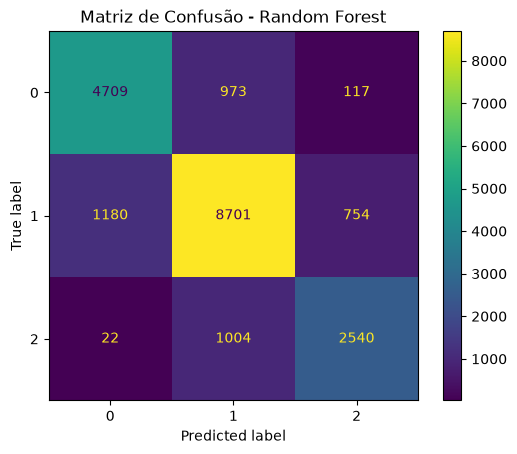

In [17]:
ver.matriz_confusao(pipeline_rf, y_test, pred)

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      5799
           1       0.81      0.82      0.82     10635
           2       0.74      0.71      0.73      3566

    accuracy                           0.80     20000
   macro avg       0.79      0.78      0.78     20000
weighted avg       0.80      0.80      0.80     20000



---
O Random Forest apresentou um desempenho satisfatório no conjunto de teste, visto que **aproximadamente 79,8% das amostras foram classificadas corretamente em suas respectivas classes,** conforme a acurácia mostra. Como o conjunto de dados possui classes desbalanceadas, o F1-score ponderado foi adotado como principal métrica de avaliação, e por ele ter um valor praticamente igual ao da acurácia, é indicado que o desempenho do modelo para as 3 classes diferentes está relativamente consistente.

Comparando o F1-score ponderado (79,7%) e o F1-score macro (78,3%), a pequena diferença entre eles mostra que existe alguma diferença de desempenho entre as classes, porém ela não é exorbitante. Pelo relatório de classificação e a matriz de confusão, percebemos que **a diferença maior de desempenho está na classificação do score Good**, que é a classe mais subrepresentada. Para essa classe, apenas 71% de seus registros foram preditos corretamente, e 1004 instâncias das 3566 pertencentes a essa classe foram confundidas com a classe Standard. Isso indica que essas categorias apresentam características semelhantes, dificultando sua distinção pelo modelo. Em contrapartida, houve poucas confusões entre as classes Poor e Good, evidenciando que o Random Forest conseguiu separar adequadamente os extremos do problema de classificação.

Por fim, o modelo teve um desempenho consistente para as classes Standard e Poor, que tiveram, respectivamente, 82% e 81% de seus registros classificados corretamente, mesmo havendo alguns exemplos dessas classes sendo confudidos entre si. **A classe Standard apresentou melhor desempenho, seguido da classe Poor e da classe Good.**

---

### 6.2 Um modelo de Machine Learning consegue classificar o score de crédito dos clientes com boa performance?

Sim, porém ainda há algumas melhorias que podem ser feitas para que o modelo opere com uma performance melhor. O Random Forest foi o modelo que apresentou o melhor desempenho, obtendo uma performance consistente com um conjunto de treino desbalanceado. Porém, com a análise da matriz de confusão foi observado que o modelo de classificação possuiu dificuldades de trabalhar com a classe subrepresentada (Good), confundindo muito ela com a classe Standard, que é a que parece possuir características mais próximas às dela. Apesar disso, o modelo diferenciou bem as classes extremas do modelo (Poor e Good), conseguindo diferenciar melhor suas características.

Com o que foi observado, conclui-se que modelos de Machine Learning são capazes de realizar a classificação do score de crédito com desempenho satisfatório, mas, neste projeto, há espaço para melhorias nos ajustes de hiperparâmetros, para que seja encontrada uma configuração que favoreça mais o aprendizado do modelo, e a adoção de técnicas de balanceamento de classes.

## 7. Interpretação do modelo

In [19]:
# recuperando o pré-processador
prep = pipeline_rf.named_steps["prep"]

# recuperando o modelo
rf = pipeline_rf.named_steps["modelo"]

# recuperando o nome das variáveis
feature_names = prep.get_feature_names_out()

In [20]:
# calcular importância das variáveis
importancias = (
    pd.DataFrame({
        "Variável": feature_names,
        "Importância": rf.feature_importances_
    })
    .sort_values("Importância", ascending=False)
)

importancias

,Variável,Importância
11,Outstanding_Debt,0.098990
5,Interest_Rate,0.077005
7,Delay_from_due_date,0.059541
9,Changed_Credit_Limit,0.052984
18,Credit_Mix,0.052526
13,Credit_History_Months,0.052392
16,Monthly_Balance,0.040875
1,Annual_Income,0.039197
4,Num_Credit_Card,0.038942
15,Amount_invested_monthly,0.038540


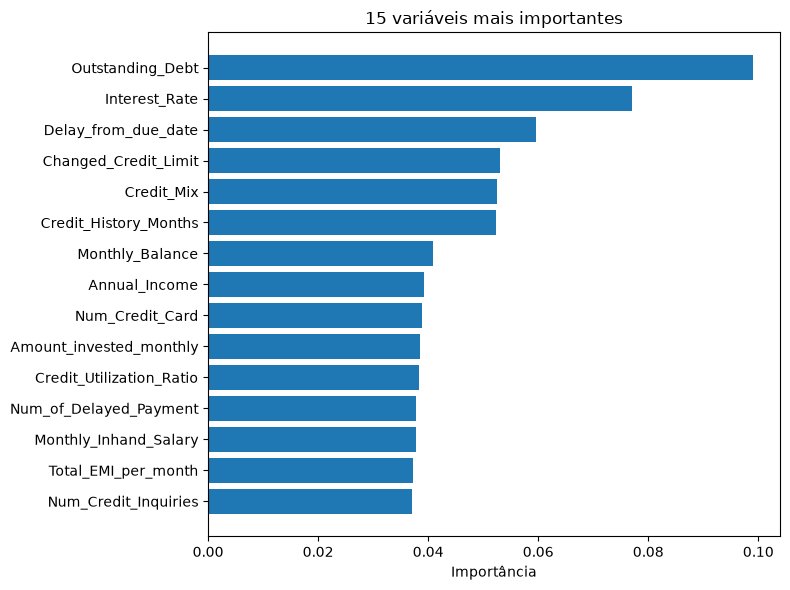

In [21]:
import matplotlib.pyplot as plt

top = 15

plt.figure(figsize=(8,6))

plt.barh(
    importancias["Variável"][:top][::-1],
    importancias["Importância"][:top][::-1]
)

plt.xlabel("Importância")
plt.title("15 variáveis mais importantes")
plt.tight_layout()

plt.show()

### 7.1 Quais variáveis podem ter maior relação com a capacidade de pagamento dos clientes?

As variáveis de dívida restante (`Outstanding_Debt`), taxa de juros (`Interest_Rate`) e número de dias de atraso do pagamento da fatura (`Delay_from_due_date`) são as mais importantes para distinguir qual o score de crédito dos clientes. As menos importantes para a diferenciação são a profissão da pessoa, seu comportamento de pagamento e quais empréstimos fez.

### 7.2 Explicação do modelo com valores SHAP

Para fazer a interpretabilidade do modelo usando SHAP, iremos usar uma amostra aleatória de 300 registros, já que usar toda a amostra de teste irá custar muito tempo.

In [22]:
import shap

/home/simires/.cache/pypoetry/virtualenvs/credit-score-classification-3H_Ct0o7-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
rng = np.random.default_rng(42)

feature_names = prep.get_feature_names_out()

X_test_trans = prep.transform(X_test)

explainer = shap.TreeExplainer(rf)

idx = rng.choice(
    X_test_trans.shape[0],
    size=300,
    replace=False
)

X_shap = X_test_trans[idx]

shap_values = explainer(X_shap)

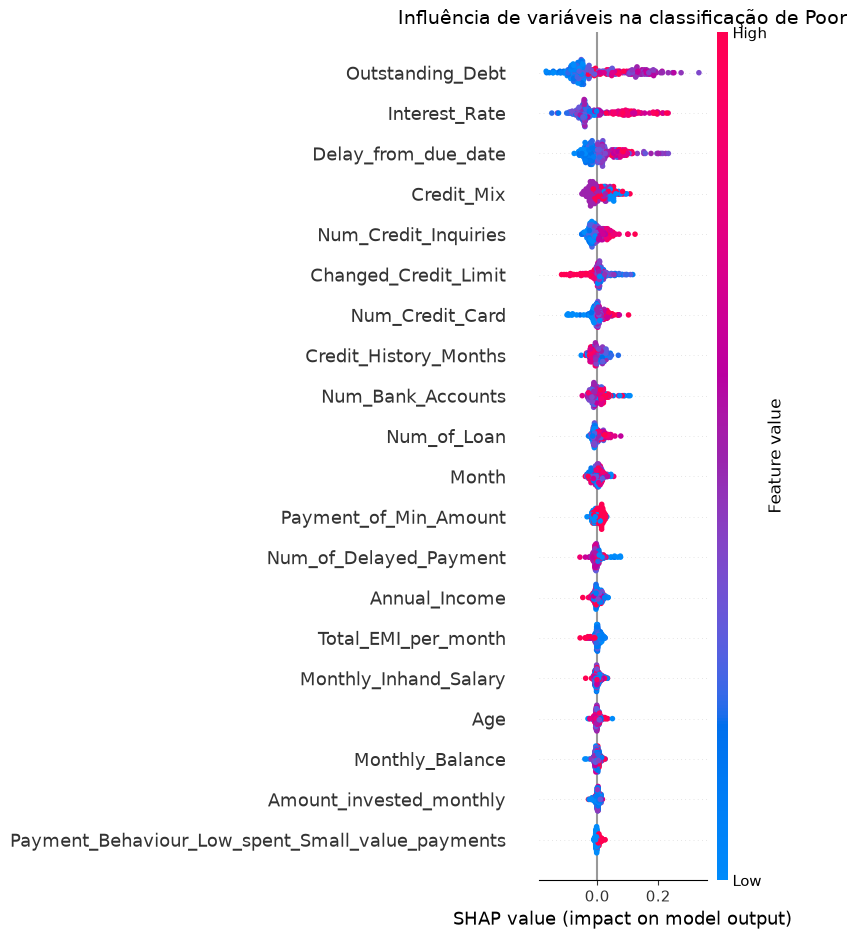

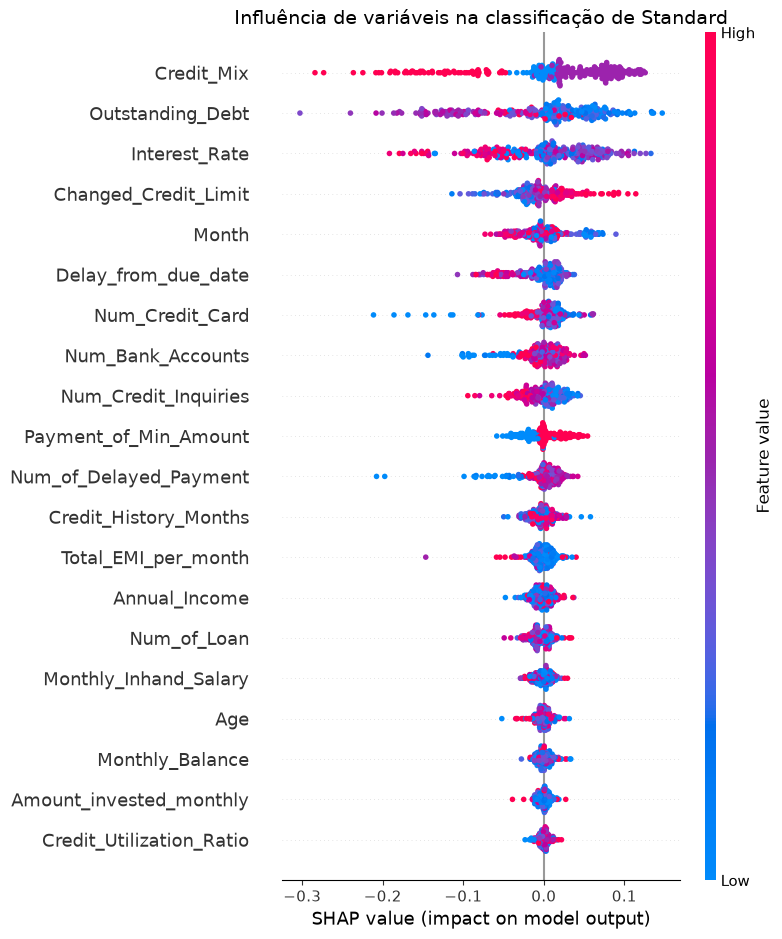

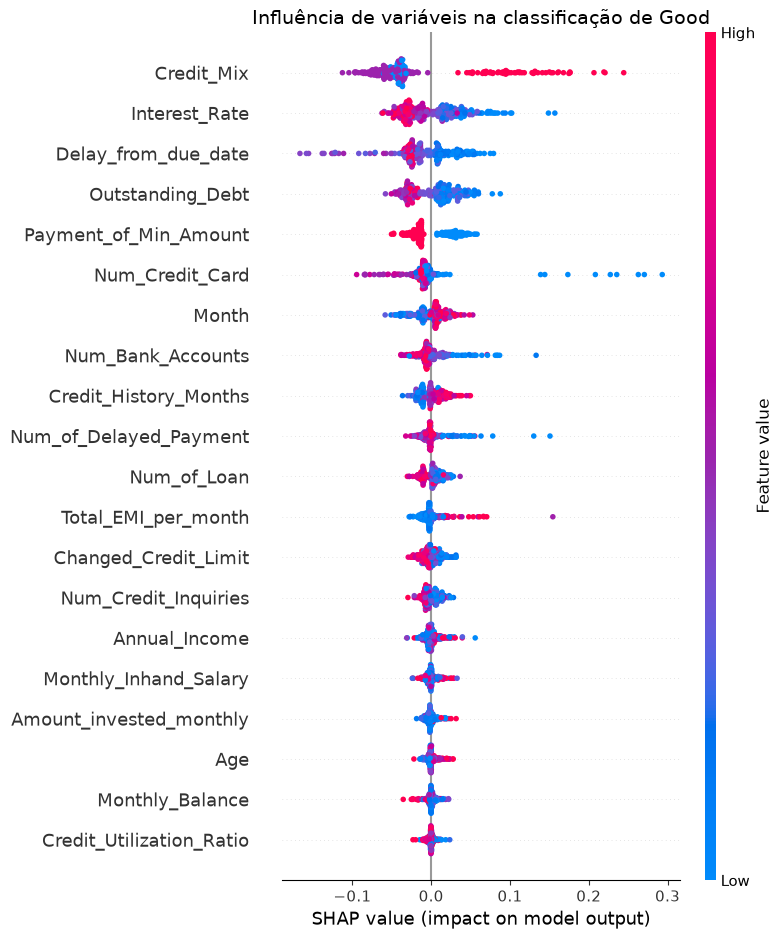

In [35]:
nomes_classes = {
    0: "Poor",
    1: "Standard",
    2: "Good"
}

for classe in rf.classes_:

    indice = list(rf.classes_).index(classe)

    shap.summary_plot(
        shap_values.values[:, :, indice],
        X_shap,
        feature_names=feature_names,
        show=False
    )

    plt.title(
        f"Influência de variáveis na classificação de {nomes_classes[classe]}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

Observamos que para classificar os clientes em diferentes scores, as variáveis mais importantes para a classificação mudam: para classificar como Poor, a que mais influencia é a dívida restante, e para classificar como Standard ou Good, a mais influente é o mix de créditos. Valores médios de Credit_Mix contribuem fortemente para que a classificação Standard, já valores altos contribuem para que seja classificado como Good.

Em seguida, as variáveis que mais contribuíram para Standard foram dívida restante, taxa de juros e variação do limite de crédito. Pessoas com dívidas restantes baixas, taxas de juros médias ou baixas e variações de limites altas foram classificadas como Standard. Como Outstanding_Debt colaborou muito com essa classificação, ela pode ter sido o ponto que mais confundiu o modelo para diferenciar Good de Standard.

Já para a classificação como Good, mix de créditos bons estão isolados na contribuição positiva, então se o valor não era bom, contribuía fortemente para não ser classificado como Good. Além disso, menores taxas de juros e menos atrasos de pagamentos possuem maior probabilidade de obter um bom score de crédito. Payment_of_Min_Amount aparece entre as cinco variáveis mais importantes apenas para a classe Good, e vemos que ele contribuiu muito para a tomada de decisão do modelo, pois pessoas que pagaram além do valor mínimo da fatura são classificadas com o score bom.

#### 7.2.1 Qual perfil de cliente possui maior probabilidade de ser classificado com score “Poor”?

Pelo gráfico de SHAP, obervamos que clientes com valores maiores de dívida restante, taxa de juros, dias de atraso de pagamento e consultas de crédito têm mais probabilidade de serem classificados como score Poor. As variáveis que mais contribuem positivamente para isso são `Outstanding_Debt` e `Interest_Rate`.

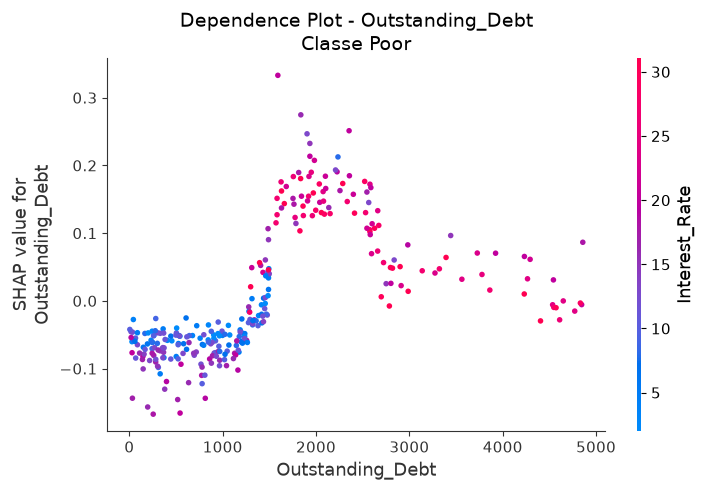

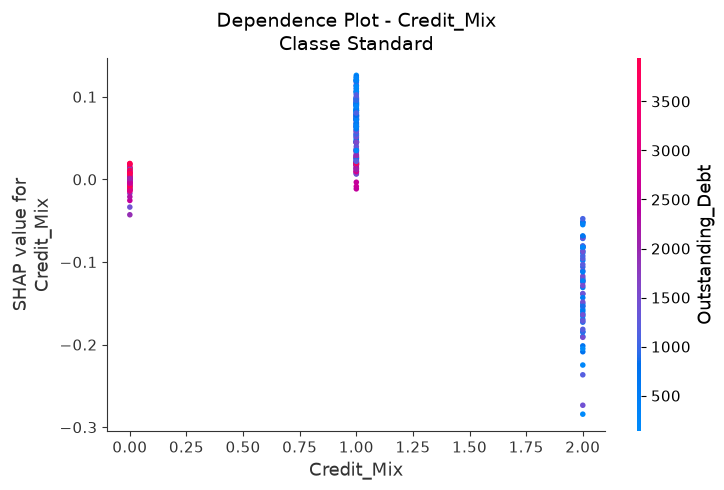

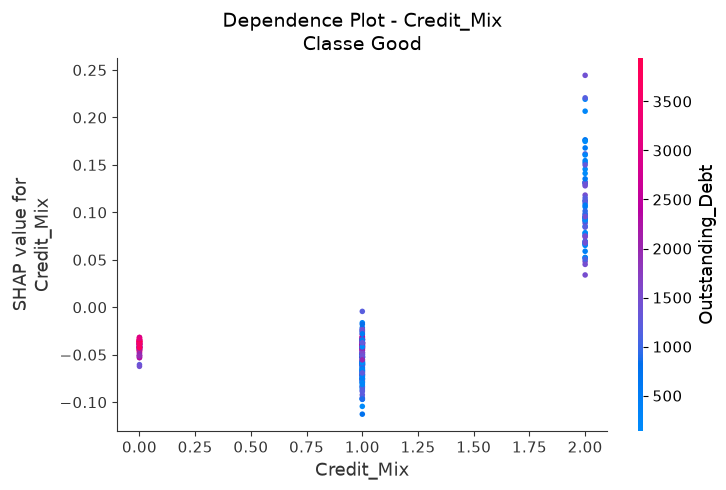

In [37]:
variaveis_principais = {
    0: "Outstanding_Debt",
    1: "Credit_Mix",
    2: "Credit_Mix"
}

for classe in rf.classes_:

    indice = list(rf.classes_).index(classe)
    variavel = variaveis_principais[classe]

    shap.dependence_plot(
        variavel,
        shap_values.values[:, :, indice],
        X_shap,
        feature_names=feature_names,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"Dependence Plot - {variavel}\nClasse {nomes_classes[classe]}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

- Até aproximadamente 1300 dólares de dívida restante, a probabilidade do cliente pertencer à classe Poor é reduzida. Entre 1500 e 2500 é a reagião de valores que mais influencia na classificação do score como Poor. Depois desse nível, aumentar ainda mais a dívida praticamente não altera a decisão do modelo. Além disso, o Shap identificou que a variável que mais interage com a dívida restante é a taxa de juros. Com dívida restante alta, há taxa de juros alta.

- Para a classificação entre Standard e Good usando mix de créditos, foi observado que pessoas com mix de crédito  intermediário influencia muito para ser classificado como Standard e influencia para não ser classificado como Good. Em contrapartida, mix de créditos bom aumenta a probabilidade de ser classificado com score bom e diminui a probabilidade de ser classificado como Standard.